In [9]:
import numpy as np # Import numpy library
import matplotlib.pyplot as plt # Import mathplot library
import datetime # Import datetime library
import pandas as pd
import math
import cv2
import seaborn as sn
import keras
from keras.datasets import mnist, cifar10 # Import MNIST dataset
from keras.models import Sequential # Import Sequential class
from keras.layers import Conv2D, Conv3D, MaxPooling2D, MaxPooling3D, AveragePooling2D # Import Conv2D, MaxPooling2D class
from keras.layers import Dense, Dropout, Flatten, BatchNormalization # Import Dense, Dropout, Flatten class
from keras.utils import to_categorical # Import numpy-related utilities
from keras.callbacks import TensorBoard # Import TensorBoard class
from keras.models import load_model # Import load\_model method
from keras.metrics import sparse_categorical_crossentropy
from tensorflow.keras.utils import plot_model # Import plot\_model method
from tensorflow.math import confusion_matrix # Import confusion matrix method
from tensorflow.keras.optimizers import Adam # Import Adam optimizer
# Import spare categorical crossentroy loss
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import activations # Import activations module
batch_size = 256 # Number of samples per gradient update
num_classes = 10 # Number of classes in the dataset
epochs = 10 # Number of epochs to


In [2]:
# x_train is a NumPy array of grayscale image data
# y_train is a NumPy array of digit labels (in range 0-9)
# x_test is a NumPy array of grayscale image data
# y_test is a NumPy array of digit labels (in range 0-9)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

"""
X_TRAIN_SIZE = 50000
X_TEST_SIZE = 10000
def convert(image):
  return cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
for i in range(X_TRAIN_SIZE):
  x_train[i] = convert(x_train[i])[:,:,None]
for i in range(X_TEST_SIZE):
  x_test[i] = convert(x_test[i])[:,:,None]
"""

"""
x_train = x_train[:,:,:,0] * 0.299 + x_train[:,:,:,1] * 0.587 + x_train[:,:,:,2] * 0.114
x_test = x_test[:,:,:,0] * 0.299 + x_test[:,:,:,1] * 0.587 + x_test[:,:,:,2] * 0.114
"""

# Print the data shape
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [5]:
model = Sequential() # Create a Sequential object
# Add a convolutional layer with 32 kernels, each of size 3x3
# Use ReLU activation function, padding="valid", strides=(1,1)
# Specify the input size to this convolutional layer: (28,28,1)
# Note: Input size needs to be specified for the first layer only
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation=activations.leaky_relu, input_shape=(32,32,3),padding="same"))
model.add(BatchNormalization())
model.add(Dropout(0.25))
# Add another convolutional layer with 64 kernels, each of size 3x3
# Use ReLU activation function, padding="valid", strides=(1,1)
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation=activations.leaky_relu,padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(3, 3), activation=activations.leaky_relu,padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(3, 3), activation=activations.leaky_relu,padding="same"))
model.add(BatchNormalization())
# Add a max pooling layer of size 2 x 2
model.add(MaxPooling2D(pool_size=(2, 2)))
# Add a dropout layer to prevent a model from overfitting
# Add a flatten layer to convert the pooled data to a single column
# that is passed to the fully-connected layer
model.add(Flatten())
model.add(Dropout(0.5))
# Add a dense layer (fully-connected layer) and use ReLU activation function
model.add(BatchNormalization())
model.add(Dense(units=128, activation=activations.leaky_relu,kernel_regularizer=keras.regularizers.l2(0.0001)))
model.add(Dense(units=64, activation=activations.leaky_relu))
# Add a dropout layer tpo prevent a model from overfitting
model.add(Dropout(0.5))
# Add a dense layer (fully-connected layer) and use Softmax activation function
model.add(Dense(units=num_classes, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,135,434 (11.96 MB)

 Trainable params: 3,101,258 (11.83 MB)

 Non-trainable params: 34,176 (133.50 KB)

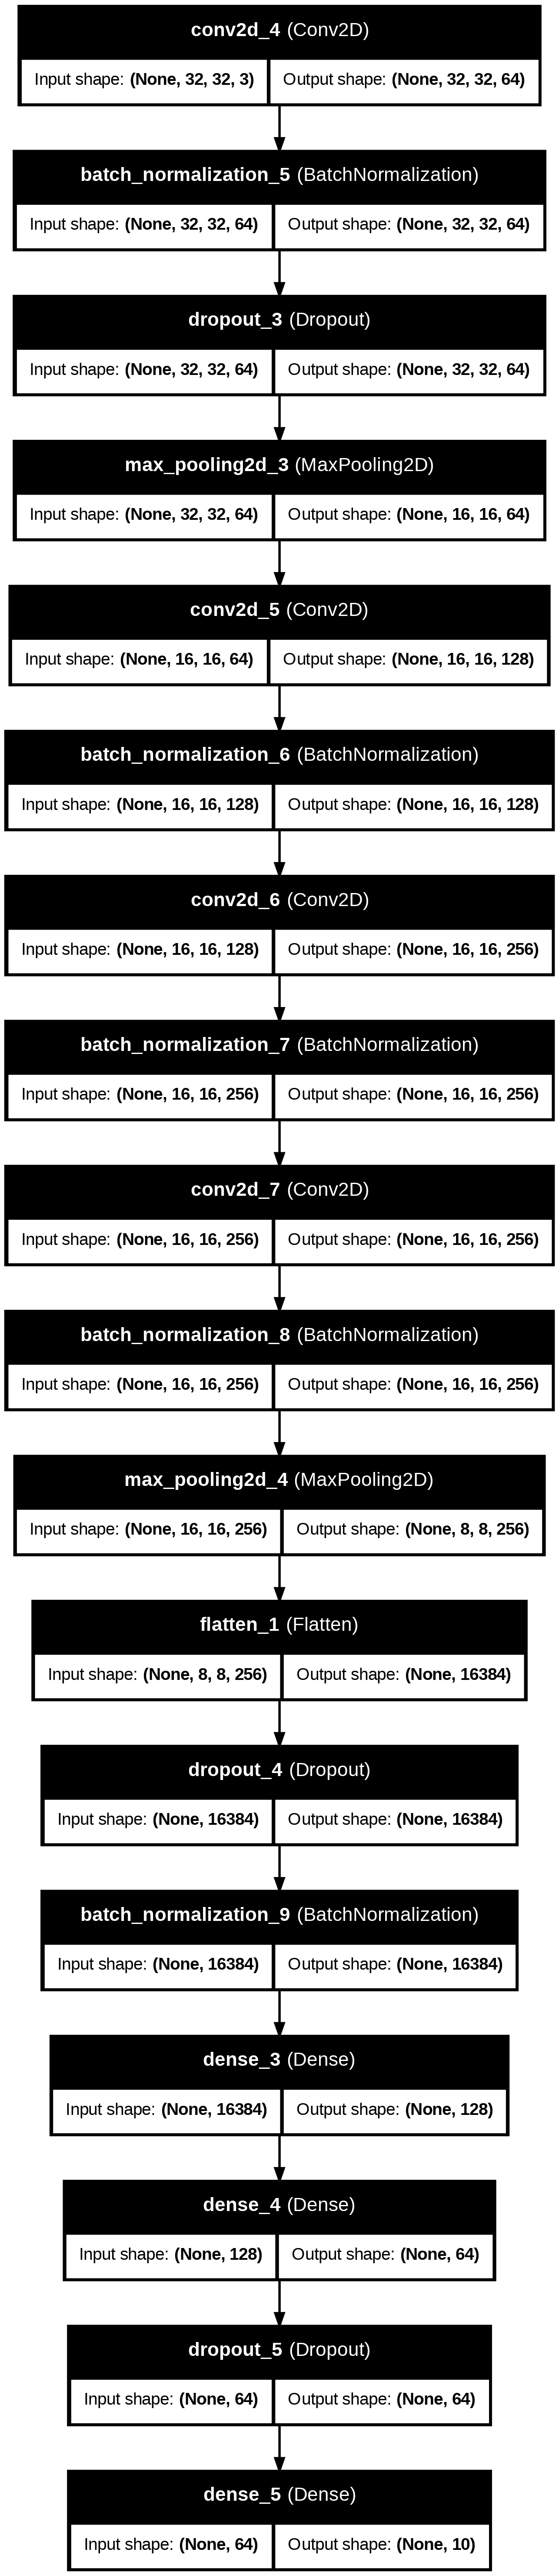

In [6]:
model.summary()
plot_model(model,
show_shapes=True,
show_layer_names=True)

In [10]:
# Create an Adam optimizer by creating an object
# Set learning rate to 0.001
# Note: Optimizers are Classes or methods used to change the attributes
# of your machine/deep learning model such as weights and learning rate
# in order to reduce the losses.
adam_optimizer = Adam(learning_rate=0.001)
# Compile the model, i.e., configures the model for training
# Use crossentropy loss function since there are two or more label classes.# Use adam algorithm (a stochastic gradient descent method)
# Use accuracy as metric, i.e., report on accuracy
model.compile(
optimizer=adam_optimizer,
loss=sparse_categorical_crossentropy,
metrics=['accuracy']
)


In [ ]:
# TensorBoard is a visualization tool, enabling us to track metrics like
# loss and accuracy, visualize the model graph, view histograms.
log_dir=".logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# log\_dir: the path of the directory where to save the log files
# histogram\_freq: frequency (in epochs) at which to compute activation
# and weight histograms for the layers of the model
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
# Fit the model, i.e., train the model
# Specify training data and labels, number of epochs to train the model,
# validation data, i.e., data on which to evaluate the loss
# Write TensorBoard logs after every batch of training to monitor
training_history = model.fit(x_train, y_train, epochs=epochs,
validation_data=(x_test, y_test),
callbacks=[tensorboard_callback]
)


Epoch 1/10
  26/1563 ━━━━━━━━━━━━━━━━━━━━ 28:18 1s/step - accuracy: 0.6353 - loss: 1.2097

In [ ]:
# Evaluate the model
# Specify testing data and labels
validation_loss, validation_accuracy = model.evaluate(x_test, y_test)
# Print loss and accuracy
print('Validation loss: ', validation_loss)
print('Validation accuracy: ', validation_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.7886 - loss: 0.7478
Validation loss:  0.7478464841842651
Validation accuracy:  0.7886000275611877


In [ ]:
model_name = 'cifar10.h5'
model.save(model_name, save_format='h5')
loaded_model = load_model(model_name)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(32, 32, 32, 3))',)
  warnings.warn(msg)


1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(None, 32, 32, 3))',)
  warnings.warn(msg)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 159s 101ms/step
predictions: (50000, 10)


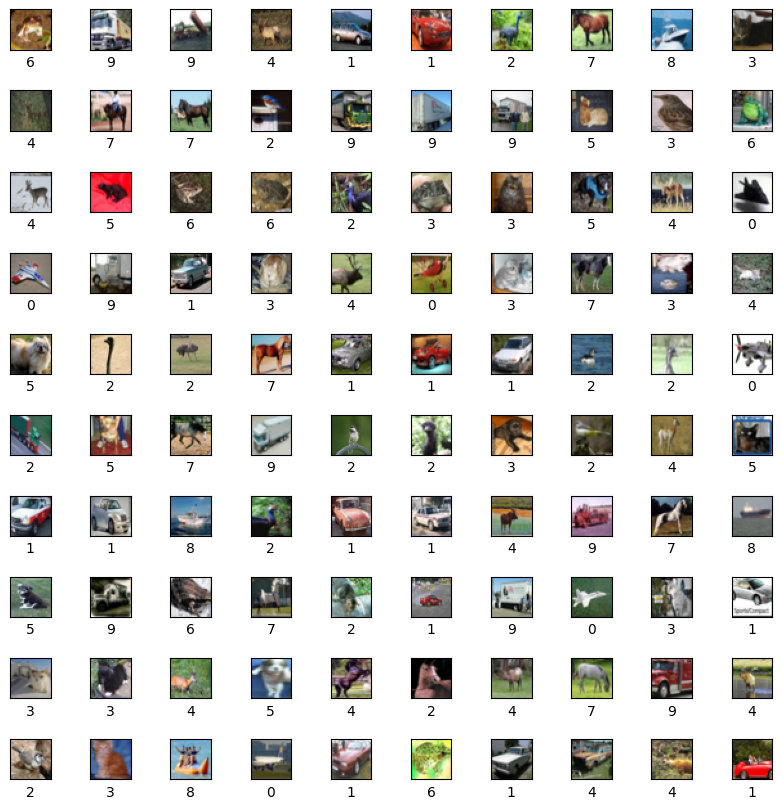

In [ ]:
predictions = loaded_model.predict([x_train])
print('predictions:', predictions.shape)
pd.DataFrame(predictions)
prediction_results = np.argmax(predictions, axis=1)
pd.DataFrame(prediction_results)
numbers_to_display = 100 # Display 196 images
# Compute number of images per row
num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize=(10, 10)) # Each image is in size 10x10 inches
# Show all the images
for i in range(numbers_to_display):
  # Number of rows, number of columns, index (start from 1)
  plt.subplot(num_cells, num_cells, i + 1)
  plt.xticks([]) # Remove all xticks
  plt.yticks([]) # Remove all yticks
  plt.grid(False) # No grid lines
  # Check if the prediction is correct. If so, display in green.
  # Otherwise in red.
  color_map = 'Greens' if prediction_results[i] == y_train[i] else 'Reds'
  plt.imshow(x_train[i], cmap=color_map) # Display data as a color image
  plt.xlabel(prediction_results[i]) # Show predicted image labels
# Adjust the height of the padding between subplots to 1
# Adjust the width of the padding between subplots to 0.5
accuracy = (prediction_results == y_train).sum()/y_train.shape
plt.subplots_adjust(hspace=1, wspace=0.5)
plt.show() # Show the figure

In [ ]:
print(accuracy)

[5.0e+03 2.5e+08]


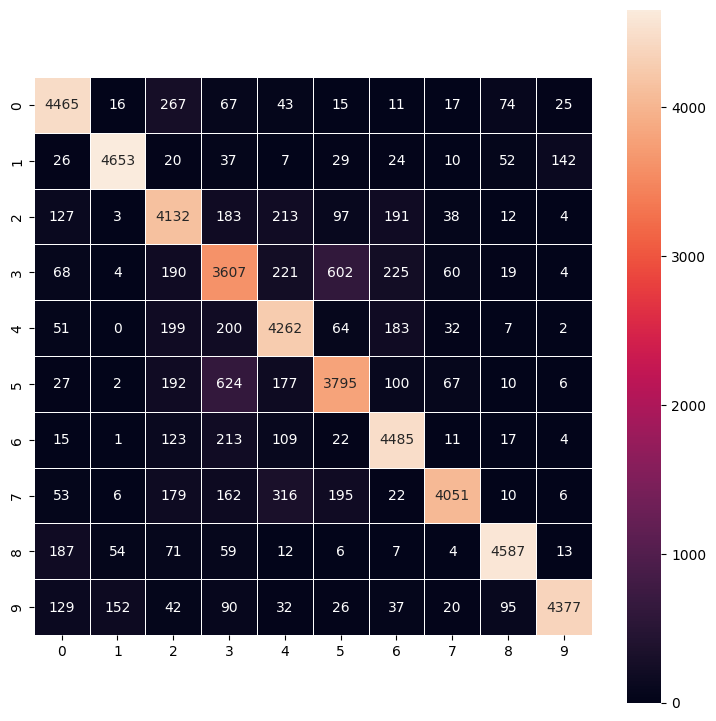

In [ ]:
# Compute confusion matrix to evaluate the accuracy of a classification
# by creating a confusion\_matrix object.
# Specify true labels and prediction results
cm = confusion_matrix(y_train, prediction_results)
# Each image is in size 9x9 inches
f, ax = plt.subplots(figsize=(9, 9))
# Draw heat map to show the magnitude in color
sn.heatmap(
cm, # data
annot=True, # Wwrite the data in each cell
linewidths=.5, # Width of line
fmt="d", # Format of the data, decimal
square=True, # Make cell as square-shaped
ax=ax # Draw it on ax
)
plt.show() # Show the figure